Используйте базу трафика с сайта компании.

Напишите модель для прогнозирования трафика.

При параметре `length = 60`, добейтесь максимально точного соответствия между графиками корреляции исходного сигнала и прогноза.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gdown

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.optimizers import Adam

plt.style.use('ggplot')

In [2]:
#Загружаем базу трафика с сайта компании
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/traff.csv', None, quiet=True)

'traff.csv'

In [3]:
# ваше решение
df = pd.read_csv('traff.csv')
df.head()

,1/1/2017,"22,226.00"
0,1/2/2017,"29,593.00"
1,1/3/2017,"31,726.00"
2,1/4/2017,"32,684.00"
3,1/5/2017,"31,820.00"
4,1/6/2017,"29,354.00"


In [4]:
# Удаление столбца с датой
df = df.drop(columns=['1/1/2017'])

In [5]:
# Преобразование строкового формата чисел в float
df['22,226.00'] = df['22,226.00'].str.replace(',', '').astype('float32')
# Перевод в numpy массив
data = df.values.astype('float32')
print(df.head())
print(df.dtypes)

   22,226.00
0    29593.0
1    31726.0
2    32684.0
3    31820.0
4    29354.0
22,226.00    float32
dtype: object


In [6]:
# Нормализация
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [7]:
# длина входной последовательности
length = 60
batch_size = 16

In [8]:
# деление на train/test по времени
train_size = int(len(data_scaled) * 0.8)

train = data_scaled[:train_size]
# тест включает length, чтобы корректно формировать окна
test = data_scaled[train_size - length:]

In [9]:
# преобразование ряда в обучающие последовательности
train_gen = TimeseriesGenerator(
    train, train,
    length=length,
    batch_size=batch_size
)
# тестовый генератор
test_gen = TimeseriesGenerator(
    test, test,
    length=length,
    batch_size=len(test)
)
# извлекаем весь тестовый набор для финального сравнения
x_test, y_test = test_gen[0]

In [41]:
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, BatchNormalization

model = Sequential([
    Conv1D(128, kernel_size=5, activation='relu', input_shape=(length, 1)),
    BatchNormalization(),

    LSTM(128, return_sequences=True),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse'
)

Обучение модели

In [42]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=50,
    verbose=1
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0716 - val_loss: 0.1021
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0390 - val_loss: 0.0632
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0360 - val_loss: 0.0426
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0308 - val_loss: 0.0678
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0216 - val_loss: 0.0794
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0197 - val_loss: 0.0762
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0165 - val_loss: 0.0672
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0116 - val_loss: 0.0974
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0091 - val_loss: 0.0836
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0074 - val_loss: 0.0720
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0074 - val_loss: 0.0768
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

In [43]:
pred = model.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [44]:
# возврат к исходному масштабу данных
pred_inv = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test)

Визуализация результата(прогноз трафика)

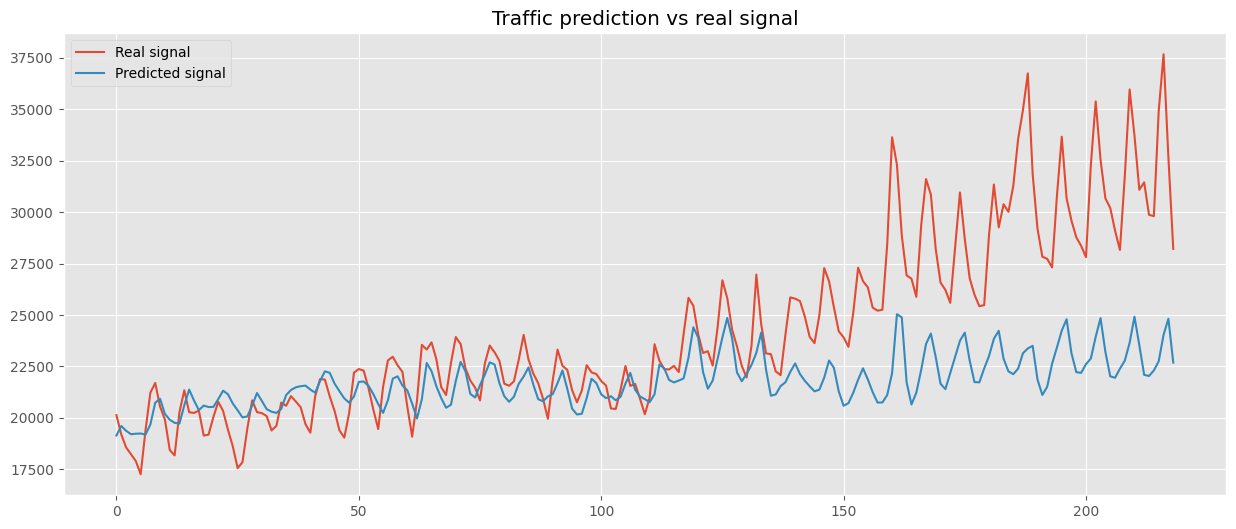

In [45]:
plt.figure(figsize=(15,6))
plt.plot(y_test_inv, label='Real signal')
plt.plot(pred_inv, label='Predicted signal')
plt.legend()
plt.title('Traffic prediction vs real signal')
plt.show()

Автокрреляция

Корреляция между графиками автокорреляции: 0.8960851143193385


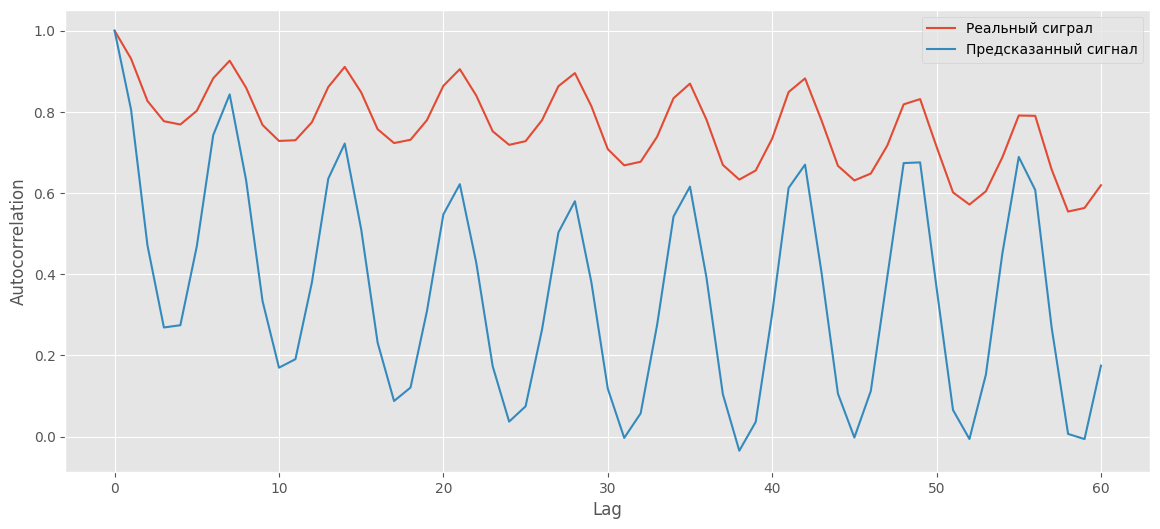

In [47]:
# Функция автокорреляции
def autocorr(x, max_lag=60):
    x = x.flatten()
    x = x - np.mean(x)
    result = []
    for lag in range(max_lag + 1):
        if lag == 0:
            result.append(1)
        else:
            result.append(np.corrcoef(x[:-lag], x[lag:])[0, 1])
    return np.array(result)

real_acf = autocorr(y_test_inv, max_lag=60)
pred_acf = autocorr(pred_inv, max_lag=60)

# Корреляция между графиками автокорреляции
acf_corr = np.corrcoef(real_acf, pred_acf)[0, 1]
print("Корреляция между графиками автокорреляции:", acf_corr)

plt.figure(figsize=(14, 6))
plt.plot(real_acf, label='Реальный сиграл')
plt.plot(pred_acf, label='Предсказанный сигнал')
plt.legend()
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()